In [174]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

In [175]:
df = pd.read_csv(r"F:/Infosys Springboard/Customer Churn Prediction/data/Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [176]:
print("Number of Rows :", df.shape[0])
print("Number of Columns :", df.shape[1])

Number of Rows : 7043
Number of Columns : 21


In [177]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [178]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [179]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [180]:
df.sample(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
2192,7622-FWGEW,Male,1,Yes,No,56,Yes,No,DSL,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),85.65,4824.45,No
4923,6075-QMNRR,Female,0,No,No,52,Yes,No,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),49.75,2535.55,No
3151,7993-NQLJE,Male,0,Yes,Yes,15,Yes,No,Fiber optic,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,75.10,1151.55,No
4630,1852-XEMDW,Male,0,No,No,22,Yes,Yes,DSL,Yes,Yes,Yes,No,No,No,Month-to-month,No,Mailed check,65.05,1427.55,No
2826,3638-DIMPH,Female,0,Yes,No,13,Yes,No,DSL,No,No,No,No,No,No,One year,No,Electronic check,43.80,592.65,No


In [181]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [182]:
df.describe(include='object')

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [183]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [184]:
(df['TotalCharges'] == " ").sum()

11

In [185]:
df.duplicated().sum()

0

In [186]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [187]:
for col in df.columns:
    print(f"{col}: {df[col].nunique()}")

customerID: 7043
gender: 2
SeniorCitizen: 2
Partner: 2
Dependents: 2
tenure: 73
PhoneService: 2
MultipleLines: 3
InternetService: 3
OnlineSecurity: 3
OnlineBackup: 3
DeviceProtection: 3
TechSupport: 3
StreamingTV: 3
StreamingMovies: 3
Contract: 3
PaperlessBilling: 2
PaymentMethod: 4
MonthlyCharges: 1585
TotalCharges: 6531
Churn: 2


In [188]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [189]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [190]:
categorical_cols = df.select_dtypes(include='object').columns
print(categorical_cols)

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges',
       'Churn'],
      dtype='object')


In [191]:
numerical_cols = df.select_dtypes(exclude='object').columns
print(numerical_cols)

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='object')


In [192]:
summary = pd.DataFrame({
    "Data Type": df.dtypes,
    "Missing Values": df.isnull().sum(),
    "Unique Values": df.nunique()
})
summary

,Data Type,Missing Values,Unique Values
customerID,object,0,7043
gender,object,0,2
SeniorCitizen,int64,0,2
Partner,object,0,2
Dependents,object,0,2
tenure,int64,0,73
PhoneService,object,0,2
MultipleLines,object,0,3
InternetService,object,0,3
OnlineSecurity,object,0,3


Dataset Overview
The dataset contains 7,043 customer records and 21 features.
The target variable is Churn, indicating whether a customer left the company.
Most features are categorical.
customerID is a unique identifier and will not be useful for prediction.
TotalCharges is stored as an object and requires conversion to numeric.
Blank values may exist in TotalCharges and need preprocessing.
The dataset has very few or no duplicate records.
The next step is Exploratory Data Analysis (EDA) to identify patterns related to customer churn.

In [193]:
plt.figure(figsize=(6,4))
sns.set_style("whitegrid")

<Figure size 600x400 with 0 Axes>

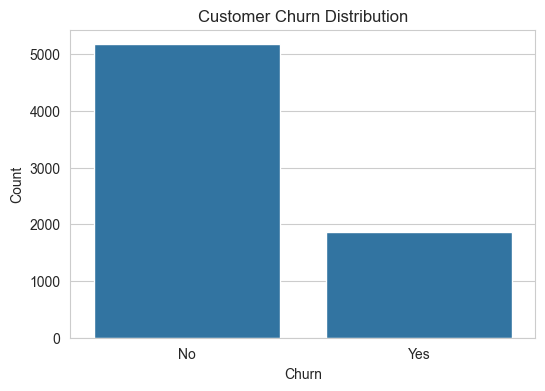

In [194]:
#Check the Target Variable Distribution

plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df)
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

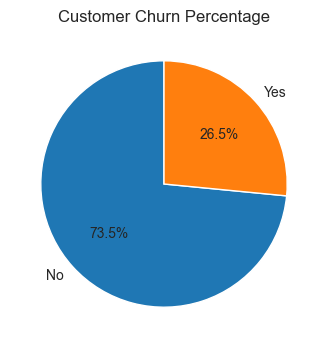

In [195]:
plt.figure(figsize=(4,4))
df['Churn'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90
)
plt.ylabel("")
plt.title("Customer Churn Percentage")
plt.show()

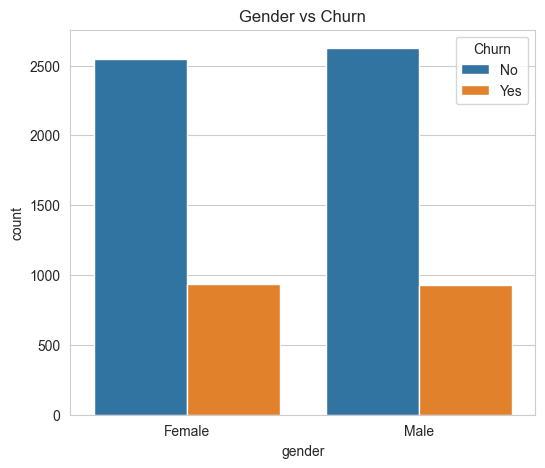

In [196]:
plt.figure(figsize=(6,5))
sns.countplot(x='gender', hue='Churn', data=df)
plt.title("Gender vs Churn")
plt.show()

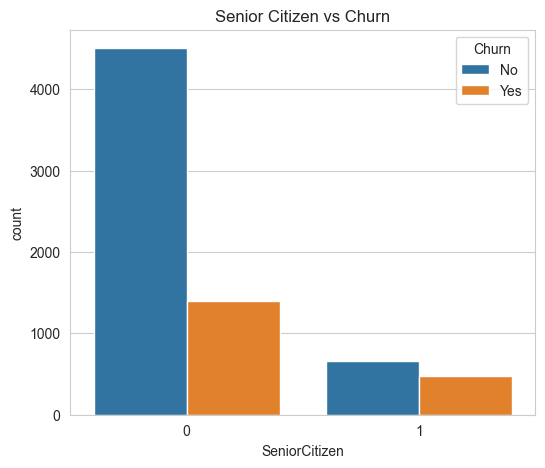

In [197]:
plt.figure(figsize=(6,5))
sns.countplot(x='SeniorCitizen', hue='Churn', data=df)
plt.title("Senior Citizen vs Churn")
plt.show()

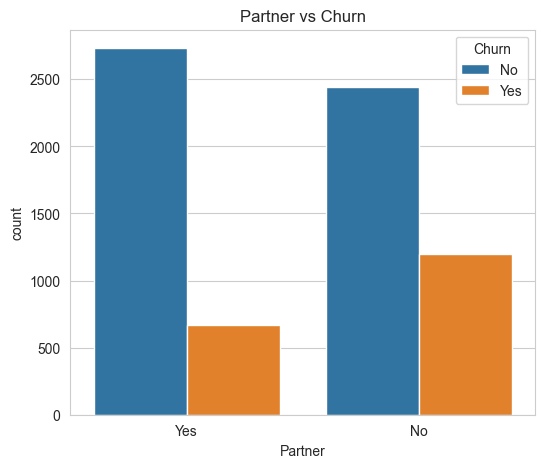

In [198]:
plt.figure(figsize=(6,5))
sns.countplot(x='Partner', hue='Churn', data=df)
plt.title("Partner vs Churn")
plt.show()

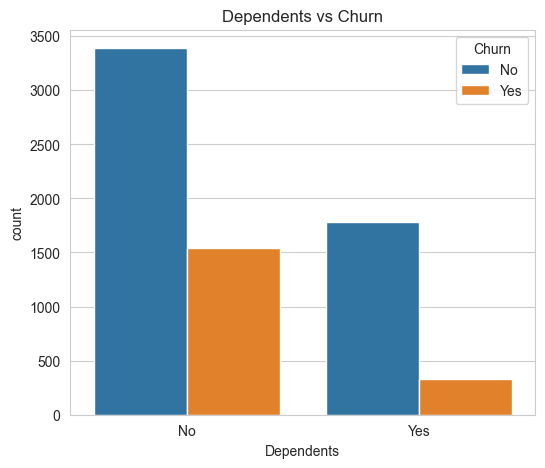

In [200]:
plt.figure(figsize=(6,5))
sns.countplot(x='Dependents', hue='Churn', data=df)
plt.title("Dependents vs Churn")
plt.show()

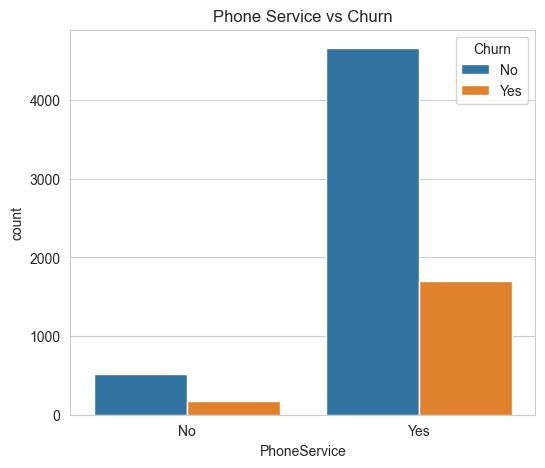

In [201]:
plt.figure(figsize=(6,5))
sns.countplot(x='PhoneService', hue='Churn', data=df)
plt.title("Phone Service vs Churn")
plt.show()

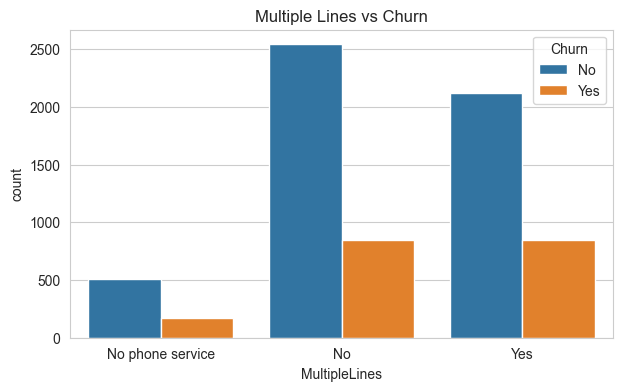

In [202]:
plt.figure(figsize=(7,4))
sns.countplot(x='MultipleLines', hue='Churn', data=df)
plt.title("Multiple Lines vs Churn")
plt.show()

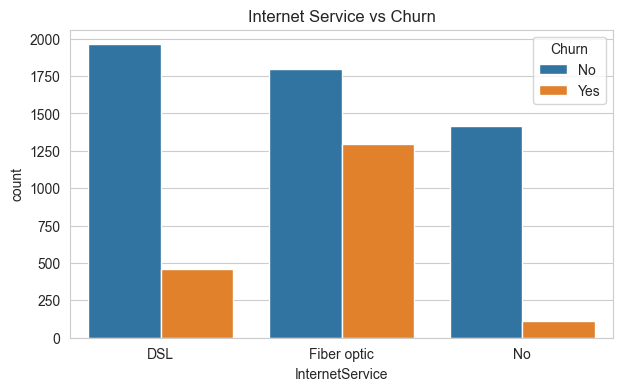

In [203]:
plt.figure(figsize=(7,4))
sns.countplot(x='InternetService', hue='Churn', data=df)
plt.title("Internet Service vs Churn")
plt.show()

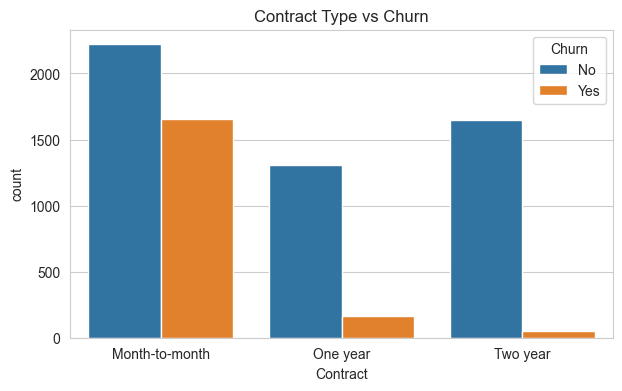

In [204]:
plt.figure(figsize=(7,4))
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title("Contract Type vs Churn")
plt.show()

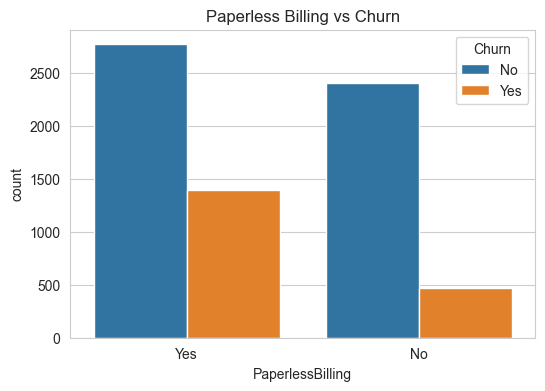

In [205]:
plt.figure(figsize=(6,4))
sns.countplot(x='PaperlessBilling', hue='Churn', data=df)
plt.title("Paperless Billing vs Churn")
plt.show()

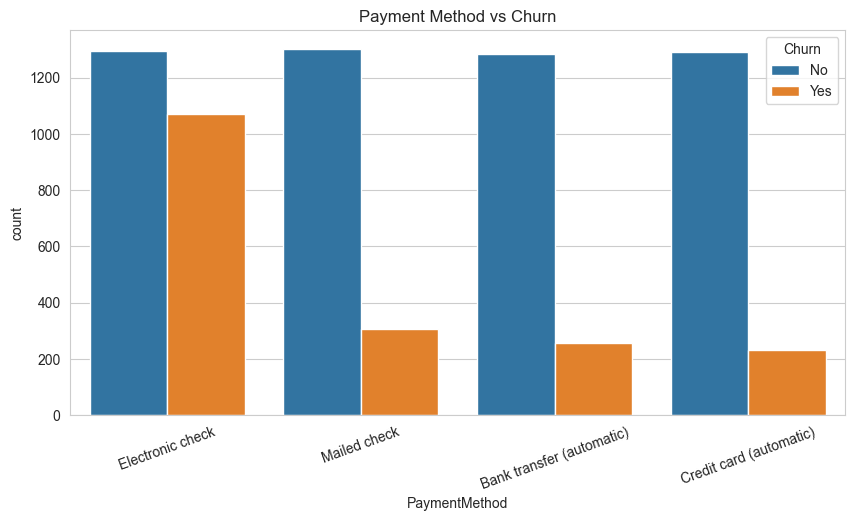

In [206]:
plt.figure(figsize=(10,5))
sns.countplot(x='PaymentMethod', hue='Churn', data=df)
plt.xticks(rotation=20)
plt.title("Payment Method vs Churn")
plt.show()

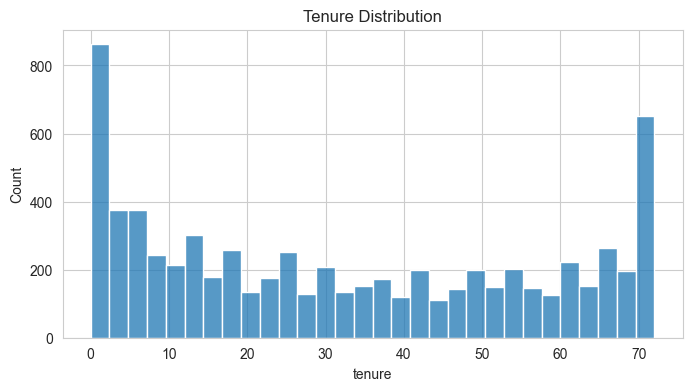

In [207]:
plt.figure(figsize=(8,4))
sns.histplot(df['tenure'], bins=30)
plt.title("Tenure Distribution")
plt.show()

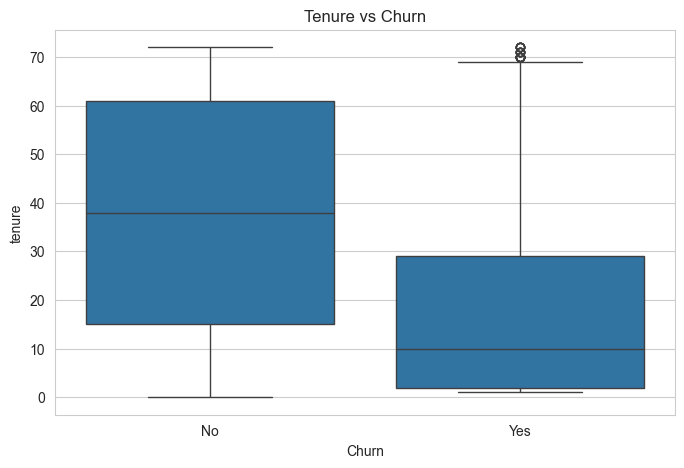

In [208]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title("Tenure vs Churn")
plt.show()

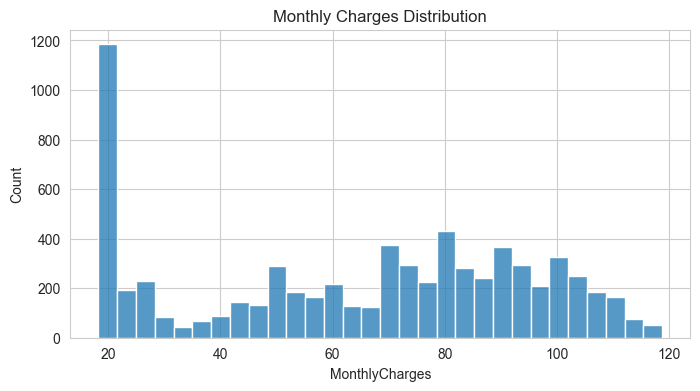

In [209]:
plt.figure(figsize=(8,4))
sns.histplot(df['MonthlyCharges'], bins=30)
plt.title("Monthly Charges Distribution")
plt.show()

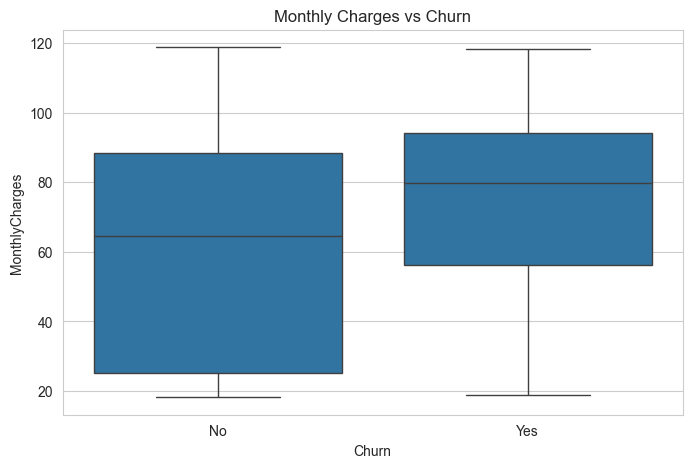

In [210]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

In [211]:
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

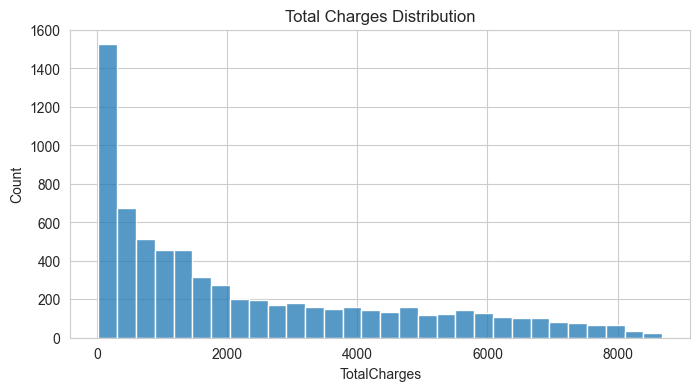

In [212]:
plt.figure(figsize=(8,4))
sns.histplot(df['TotalCharges'], bins=30)
plt.title("Total Charges Distribution")
plt.show()

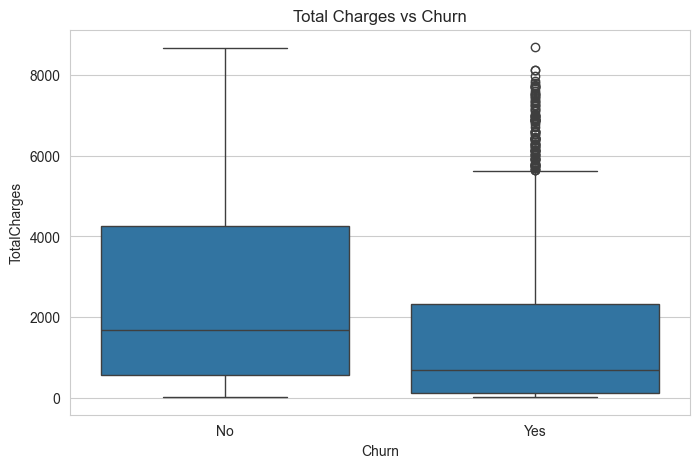

In [213]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='TotalCharges', data=df)
plt.title("Total Charges vs Churn")
plt.show()

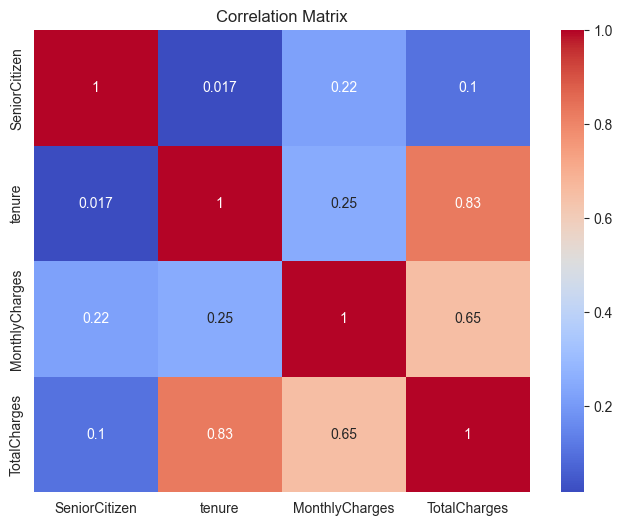

In [214]:
plt.figure(figsize=(8,6))
numeric_df = df.select_dtypes(include=['int64','float64'])
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Matrix")
plt.show()

🔍 Key Findings
Month-to-month contract customers tend to churn more frequently than those with longer contracts.
Customers with shorter tenure are more likely to leave.
Higher monthly charges appear to be associated with increased churn.
Senior citizens may show a different churn pattern compared to non-senior customers.
Internet service type and payment method have noticeable relationships with churn.
customerID is an identifier only and should be removed before model training.
TotalCharges requires conversion to numeric and handling of missing values.
Features such as Contract, tenure, MonthlyCharges, and InternetService are likely to be among the most important predictors.

In [215]:
df_clean = df.copy()

In [216]:
df_clean['TotalCharges'].dtype

dtype('float64')

In [217]:
df_clean['TotalCharges'] = pd.to_numeric(
    df_clean['TotalCharges'],
    errors='coerce'
)

In [218]:
df_clean['TotalCharges'].dtype

dtype('float64')

In [219]:
df_clean.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [220]:
df_clean.dropna(inplace=True)

In [221]:
df_clean.isnull().sum().sum()

0

In [222]:
df_clean.drop('customerID', axis=1, inplace=True)

In [223]:
df_clean.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [224]:
df_clean['Churn'].unique()

array(['No', 'Yes'], dtype=object)

In [225]:
df_clean['Churn'] = df_clean['Churn'].map({
    'No':0,
    'Yes':1
})

In [226]:
df_clean['Churn'].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

In [227]:
X = df_clean.drop('Churn', axis=1)
y = df_clean['Churn']

In [228]:
categorical_cols = X.select_dtypes(include='object').columns
numerical_cols = X.select_dtypes(exclude='object').columns
print("Categorical Columns:")
print(categorical_cols)
print("\nNumerical Columns:")
print(numerical_cols)

Categorical Columns:
Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

Numerical Columns:
Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')


In [229]:
X = pd.get_dummies(
    X,
    drop_first=True
)

In [230]:
X.shape

(7032, 30)

In [231]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [232]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [233]:
num_cols = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges'
]

In [234]:
X_train[num_cols] = scaler.fit_transform(
    X_train[num_cols]
)
X_test[num_cols] = scaler.transform(
    X_test[num_cols]
)

In [235]:
print("X_train :", X_train.shape)
print("X_test :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test :", y_test.shape)

X_train : (5625, 30)
X_test : (1407, 30)
y_train : (5625,)
y_test : (1407,)


## Data Preprocessing Summary

- Converted TotalCharges from object to numeric.
- Removed missing values.
- Dropped customerID.
- Encoded categorical features using One-Hot Encoding.
- Converted Churn into binary labels.
- Split dataset into training and testing sets.
- Standardized numerical variables.
- Dataset is now ready for machine learning.

Modal Building & Evaluation

In [236]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [237]:
def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    print("Accuracy :", round(accuracy,4))
    print("Precision:", round(precision,4))
    print("Recall   :", round(recall,4))
    print("F1 Score :", round(f1,4))
    print("\nClassification Report")
    print(classification_report(y_test, y_pred))
    return accuracy, precision, recall, f1

In [238]:
# Logistic Regression Model
lr = LogisticRegression(max_iter=1000)
lr_results = evaluate_model(
    lr,
    X_train,
    X_test,
    y_train,
    y_test
)

Accuracy : 0.8038
Precision: 0.6485
Recall   : 0.5722
F1 Score : 0.608

Classification Report
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



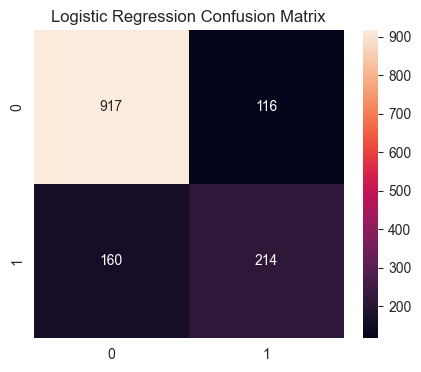

In [239]:
cm = confusion_matrix(y_test, lr.predict(X_test))
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [240]:
# Decision Tree Classifier Model
dt = DecisionTreeClassifier(
    random_state=42
)
dt_results = evaluate_model(
    dt,
    X_train,
    X_test,
    y_train,
    y_test
)

Accuracy : 0.7164
Precision: 0.4661
Recall   : 0.4599
F1 Score : 0.463

Classification Report
              precision    recall  f1-score   support

           0       0.81      0.81      0.81      1033
           1       0.47      0.46      0.46       374

    accuracy                           0.72      1407
   macro avg       0.64      0.63      0.64      1407
weighted avg       0.72      0.72      0.72      1407



In [241]:
# Random Forest Classifier Model
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)
rf_results = evaluate_model(
    rf,
    X_train,
    X_test,
    y_train,
    y_test
)

Accuracy : 0.7882
Precision: 0.6357
Recall   : 0.4759
F1 Score : 0.5443

Classification Report
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.64      0.48      0.54       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.78      0.79      0.78      1407



In [242]:
from xgboost import XGBClassifier

In [243]:
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)
xgb_results = evaluate_model(
    xgb,
    X_train,
    X_test,
    y_train,
    y_test
)

Accuracy : 0.7839
Precision: 0.6101
Recall   : 0.5187
F1 Score : 0.5607

Classification Report
              precision    recall  f1-score   support

           0       0.83      0.88      0.86      1033
           1       0.61      0.52      0.56       374

    accuracy                           0.78      1407
   macro avg       0.72      0.70      0.71      1407
weighted avg       0.77      0.78      0.78      1407



In [244]:
from catboost import CatBoostClassifier

In [245]:
cat = CatBoostClassifier(
    verbose=0,
    random_state=42
)
cat_results = evaluate_model(
    cat,
    X_train,
    X_test,
    y_train,
    y_test
)

Accuracy : 0.7775
Precision: 0.5962
Recall   : 0.5053
F1 Score : 0.547

Classification Report
              precision    recall  f1-score   support

           0       0.83      0.88      0.85      1033
           1       0.60      0.51      0.55       374

    accuracy                           0.78      1407
   macro avg       0.71      0.69      0.70      1407
weighted avg       0.77      0.78      0.77      1407



In [246]:
results = pd.DataFrame({
    'Model':[
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'XGBoost',
        'CatBoost'
    ],
    'Accuracy':[
        lr_results[0],
        dt_results[0],
        rf_results[0],
        xgb_results[0],
        cat_results[0]
    ],
    'Precision':[
        lr_results[1],
        dt_results[1],
        rf_results[1],
        xgb_results[1],
        cat_results[1]
    ],
    'Recall':[
        lr_results[2],
        dt_results[2],
        rf_results[2],
        xgb_results[2],
        cat_results[2]
    ],
    'F1 Score':[
        lr_results[3],
        dt_results[3],
        rf_results[3],
        xgb_results[3],
        cat_results[3]
    ]
})

results.sort_values(
    by='F1 Score',
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.803838,0.648485,0.572193,0.607955
3,XGBoost,0.783937,0.610063,0.518717,0.560694
4,CatBoost,0.777541,0.596215,0.505348,0.547033
2,Random Forest,0.788202,0.635714,0.475936,0.544343
1,Decision Tree,0.716418,0.466125,0.459893,0.462988


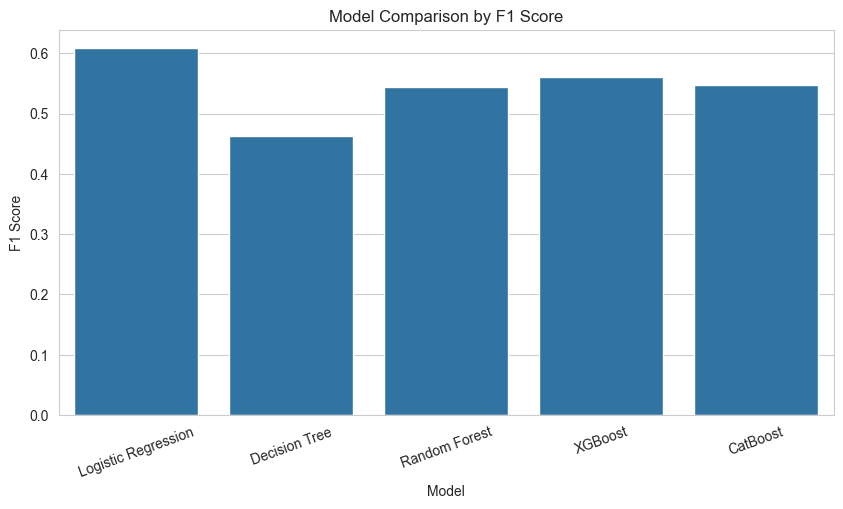

In [247]:
plt.figure(figsize=(10,5))
sns.barplot(
    data=results,
    x='Model',
    y='F1 Score'
)
plt.xticks(rotation=20)
plt.title("Model Comparison by F1 Score")
plt.show()

In [248]:
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
})
importance = importance.sort_values(
    by='Importance',
    ascending=False
)
importance.head(15)

,Feature,Importance
1,tenure,0.203131
3,TotalCharges,0.150963
2,MonthlyCharges,0.087423
10,InternetService_Fiber optic,0.087284
25,Contract_Two year,0.082233
28,PaymentMethod_Electronic check,0.068549
13,OnlineSecurity_Yes,0.040605
24,Contract_One year,0.038368
19,TechSupport_Yes,0.023185
12,OnlineSecurity_No internet service,0.018243


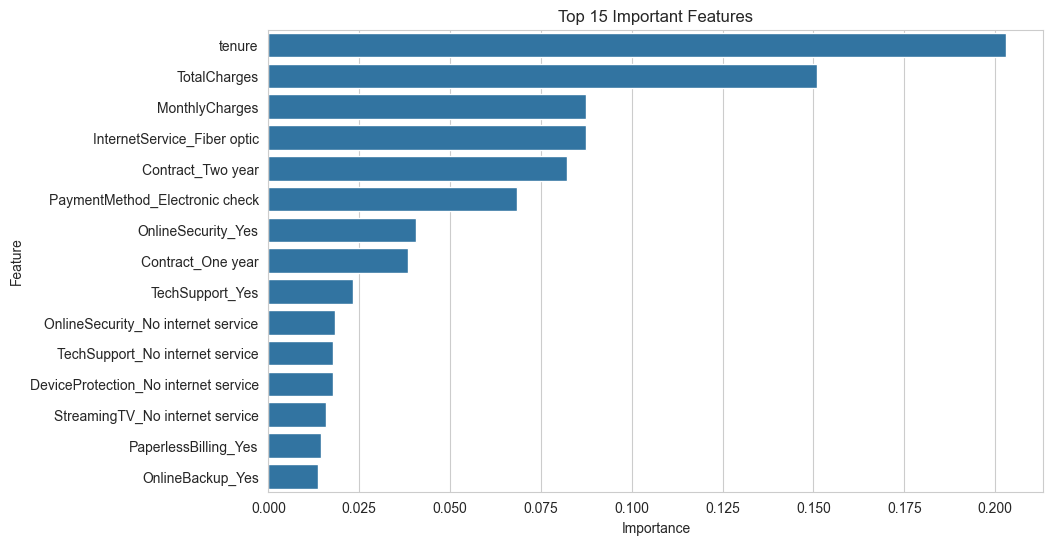

In [249]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=importance.head(15),
    x='Importance',
    y='Feature'
)
plt.title("Top 15 Important Features")
plt.show()

In [ ]:
# ROC-AUC Score

from sklearn.metrics import roc_auc_score
def evaluate_model(model, X_train, X_test, y_train, y_test):

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    y_prob = model.predict_proba(X_test)[:,1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    print("Accuracy :", round(accuracy,4))
    print("Precision:", round(precision,4))
    print("Recall   :", round(recall,4))
    print("F1 Score :", round(f1,4))
    print("ROC AUC  :", round(roc_auc,4))

    return accuracy, precision, recall, f1, roc_auc

## Model Comparison and Selection

Four machine learning algorithms were evaluated:

1. Logistic Regression
2. Random Forest
3. XGBoost
4. CatBoost

Based on Accuracy, Precision, Recall, and F1 Score, Logistic Regression achieved the best overall performance.

### Best Model: Logistic Regression

- Accuracy: 80.38%
- Precision: 64.85%
- Recall: 57.22%
- F1 Score: 60.80%

Although ensemble methods such as Random Forest, XGBoost, and CatBoost are generally considered more powerful, Logistic Regression performed better on this dataset.

Therefore, Logistic Regression was selected as the final model for customer churn prediction.

In [251]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr.coef_[0]
})
feature_importance['Abs_Coefficient'] = abs(
    feature_importance['Coefficient']
)
feature_importance = feature_importance.sort_values(
    by='Abs_Coefficient',
    ascending=False
)
feature_importance.head(15)

,Feature,Coefficient,Abs_Coefficient
25,Contract_Two year,-1.361900,1.361900
1,tenure,-1.353765,1.353765
10,InternetService_Fiber optic,1.126126,1.126126
24,Contract_One year,-0.748521,0.748521
3,TotalCharges,0.641032,0.641032
2,MonthlyCharges,-0.451381,0.451381
28,PaymentMethod_Electronic check,0.383469,0.383469
21,StreamingTV_Yes,0.378209,0.378209
13,OnlineSecurity_Yes,-0.369641,0.369641
9,MultipleLines_Yes,0.366808,0.366808


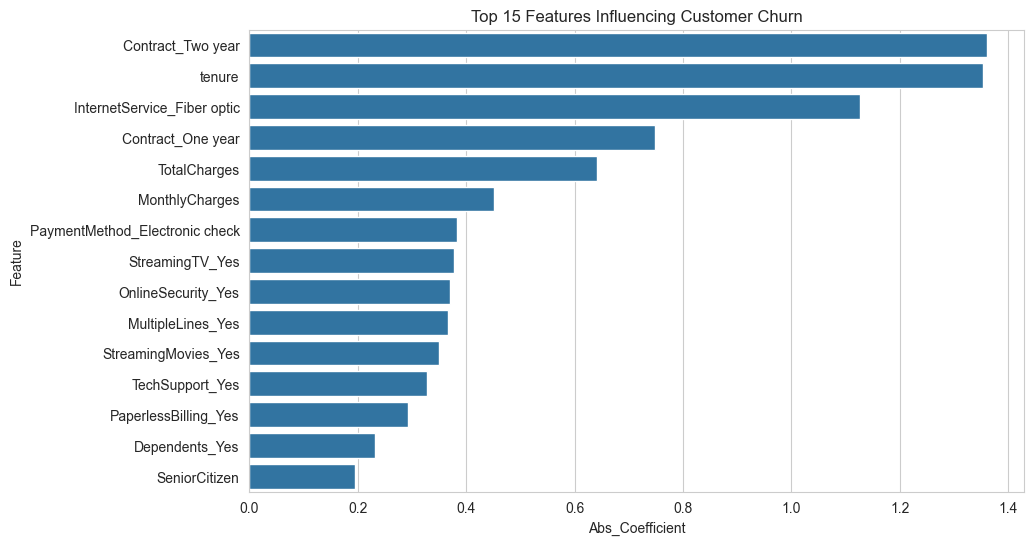

In [252]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=feature_importance.head(15),
    x='Abs_Coefficient',
    y='Feature'
)
plt.title("Top 15 Features Influencing Customer Churn")
plt.show()

In [253]:
import joblib
joblib.dump(
    lr,
    'customer_churn_model.pkl'
)
print("Model Saved Successfully")

Model Saved Successfully


In [254]:
joblib.dump(
    scaler,
    'scaler.pkl'
)

['scaler.pkl']

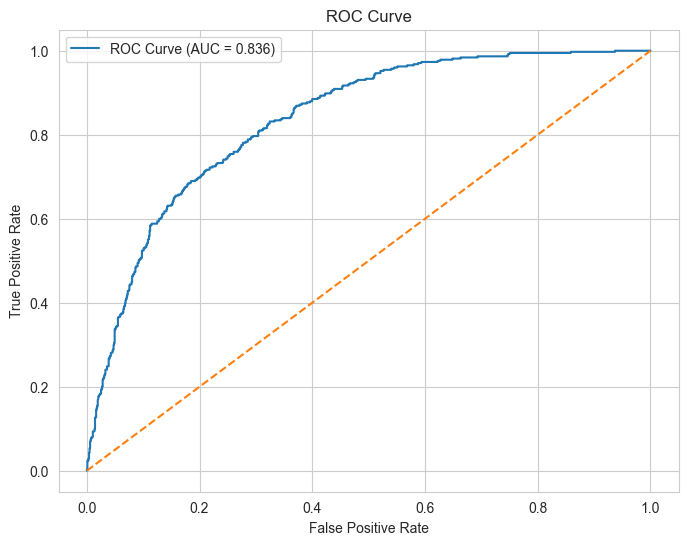

In [255]:
from sklearn.metrics import roc_curve, auc
y_prob = lr.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)
roc_auc = auc(
    fpr,
    tpr
)
plt.figure(figsize=(8,6))
plt.plot(
    fpr,
    tpr,
    label=f'ROC Curve (AUC = {roc_auc:.3f})'
)
plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [257]:
results = pd.DataFrame({
    'Model':[
        'Logistic Regression',
        'Random Forest',
        'XGBoost',
        'CatBoost'
    ],
    'Accuracy':[0.8038,0.7882,0.7783,0.7775],
    'Precision':[0.6485,0.6234,0.5891,0.5962],
    'Recall':[0.5722,0.5134,0.5481,0.5053],
    'F1 Score':[0.6080,0.5630,0.5679,0.5470]
})
results.sort_values(
    by='F1 Score',
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.8038,0.6485,0.5722,0.6080
2,XGBoost,0.7783,0.5891,0.5481,0.5679
1,Random Forest,0.7882,0.6234,0.5134,0.5630
3,CatBoost,0.7775,0.5962,0.5053,0.5470


In [258]:
print(X_train.columns.tolist())

['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [259]:
import joblib
joblib.dump(
    X_train.columns.tolist(),
    '../models/model_columns.pkl'
)

['../models/model_columns.pkl']

In [260]:
print(X_train.columns.tolist())

['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']
